# U-Net for Burned Area Mapping using NRBR — Part 2: Prediction & Mosaicking.

This notebook loads a pre-trained U-Net model and applies it to new unseen satellite imagery patches (Canada test area) to perform burned area mapping. It evaluates accuracy metrics, reconstructs the full predicted image by assembling patch-level predictions, and exports the final burned area map as a GeoTIFF raster file.

## 1. Libraries to be installed

Installs the patchify library, which enables splitting large images into patches and reassembling them back into a full image.

In [ ]:
!pip install patchify

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 86.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


## 2. Libraries to be used:

Imports all required libraries for data processing, deep learning inference, evaluation metrics, patch reconstruction, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from pathlib import Path
from patchify import patchify, unpatchify
from sklearn.preprocessing import StandardScaler

## 3. Connecting to Google Drive

Connects the Colab runtime to Google Drive to access training data, model weights, and output directories.

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Check GPU Availability

Verifies that a GPU is available in the runtime; raises an error if no GPU is detected to prevent slow CPU-only training.

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## 5. Collect TFRecord File Paths (Test Area)

Reading patches dowloaded from Earth Engine. Scans the target folder for all TFRecord files matching the expected filename prefix, building a list of paths for the new test regions.

In [ ]:
file_prefix = 'Port'
# Create a path to the exported folder
path = Path('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4')

paths = [f for f in path.iterdir() if file_prefix in f.stem]
paths

[PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00000.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00001.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00002.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00003.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00004.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00005.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-00006.tfrecord.gz'),
 PosixPath('/content/drive/MyDrive/00_PhD/papers/03/tfrecord/canada/1_NRBR/tst4/Port-mixer.json')]

Display Patch Metadata:

Reads the JSON mixer file exported from Google Earth Engine to retrieve patch dimensions, total patch count, and grid layout for the test area.

In [ ]:
import json
#load the mixer json
json_file = str(path/(file_prefix+'-mixer.json'))
json_text = !cat "{json_file}"

mixer = json.loads(json_text.nlstr)
mixer

{'projection': {'crs': 'EPSG:4326',
  'affine': {'doubleMatrix': [8.983152841195215e-05,
    0.0,
    -121.38970366918458,
    0.0,
    -8.983152841195215e-05,
    51.461518186769794]}},
 'patchDimensions': [256, 256],
 'patchesPerRow': 46,
 'totalPatches': 1242}

Extract Grid Dimensions from Metadata:

Parses the mixer JSON to extract patch width, height, total patches, patches per row, and the number of columns in the patch grid.

In [ ]:
# Get relevant info from the JSON mixer file.
patch_width = mixer['patchDimensions'][0]
patch_height = mixer['patchDimensions'][1]
patches = mixer['totalPatches']
row = mixer['patchesPerRow']
col = patches//row
patch_dimensions_flat = [patch_width, patch_height]
patch_dimensions_flat, row, col

([256, 256], 46, 27)

Define TFRecord Feature Schema:

Creates the parsing dictionary that maps band names (NRBRcombined, label) to their expected tensor shapes and data types for TFRecord decoding.

In [ ]:
bands = ['NRBRcombined', 'label']
image_columns = [tf.io.FixedLenFeature(shape=patch_dimensions_flat, dtype=tf.float32) for k in bands]

#bands += ['classes']
image_columns += [tf.io.FixedLenFeature(shape=patch_dimensions_flat, dtype=tf.int64)]

# Parsing dictionary
image_features_dict = dict(zip(bands, image_columns))
image_features_dict

{'NRBRcombined': FixedLenFeature(shape=[256, 256], dtype=tf.float32, default_value=None),
 'label': FixedLenFeature(shape=[256, 256], dtype=tf.float32, default_value=None)}

Define TFRecord Parsing Function:

Wraps the feature dictionary into a function that decodes individual TFRecord examples during dataset loading.

In [ ]:
# Parsing function.
def parse_image(example_proto):
  return tf.io.parse_single_example(example_proto, image_features_dict)

## 6. Load Patches into Arrays

Reads all TFRecord files from the test area, extracts image and label patches for every sample, and stores them in memory — without filtering, since this is a full-area prediction task.


In this step, patches downloaded for GEE will be saved as arrays with shape (a, b, c, d). Where a represents the number of patches, b and c represent the patch dimension and d represents the number of bands for each patch.

In [ ]:
# --- Initialize patch containers ---
bands = 1  # number of input bands
array_image = np.zeros((patch_width, patch_height, bands))  # image patch array
array_label = np.zeros((patch_width, patch_height, 1))      # label patch array

Xl = []  # list to store image patches
yl = []  # list to store label patches

bands_image = ['NRBRcombined']
bands_label = ['label']

# --- Iterate over all TFRecord files ---
for file_idx in range(len(paths)-1):  # loop through all file paths
    image_dataset = tf.data.TFRecordDataset(str(paths[file_idx]), compression_type='GZIP')
    ds = image_dataset.map(parse_image, num_parallel_calls=10)
    arr = list(ds.as_numpy_iterator())  # convert dataset to list of examples

    # --- Loop over each sample in the file ---
    for sample in arr:
        # Build the image patch
        for i, bname in enumerate(bands_image):
            array_image[:, :, i] = sample[bname]

        # Build the corresponding label patch
        for i, bname in enumerate(bands_label):
            array_label[:, :, i] = sample[bname]

        # Append a copy of the patch to the lists
        Xl.append(array_image.copy())
        yl.append(array_label.copy())

Then, patches can be converted to array. So, in total we have 108 patches with 512*512 for both image and labeling data.

In [ ]:
X = np.array(Xl)
y = np.array(yl)

# print basic details
print('Input features shape:', X.shape)
print('\nInput labels shape:', y.shape)

Input features shape: (1242, 256, 256, 1)

Input labels shape: (1242, 256, 256, 1)


## 7. Handle NaN Values

Replaces any NaN values in both image and label arrays with zeros to ensure clean input to the model.

In [ ]:
# replacing nan -> 0
X[np.isnan(X)] = 0

# replacing nan -> 0
y[np.isnan(y)] = 0

## 8. Normalize Input Data

Applies StandardScaler normalization per spectral band to match the preprocessing used during training.

In [ ]:
# normalizing data
for i in range(X.shape[3]):
    band = X[:, :, :, i]
    band_normalized = StandardScaler().fit_transform(band.reshape(-1, 1)).reshape(X.shape[0], 256, 256)
    X[:, :, :, i] = band_normalized

# Verifying the new dimensions (shape)
print("Normalized array:", X.shape)

Normalized array: (1242, 256, 256, 1)


Print Label Value Range:

Prints the minimum and maximum values in the label array to confirm the expected class range for the test region.

In [ ]:
# details
print('Values in input features, min: %d & max: %d' % (np.min(y), np.max(y)))

Values in input features, min: 0 & max: 1


Assign Test Arrays:

Assigns the preprocessed arrays to Xtest and ytest variables and prints their shapes for confirmation.

In [ ]:
Xtest = X; ytest = y

# veamos los datos
Xtest.shape, ytest.shape

((1242, 256, 256, 1), (1242, 256, 256, 1))

## 9. One-Hot Encode Test Labels

Converts integer class labels into one-hot categorical vectors required for comparison with the softmax model output.

In [ ]:
n_classes = len(np.unique(y))
ytest_catego = to_categorical(ytest, num_classes = n_classes)

# veamos los datos
Xtest.shape,ytest_catego.shape

((1242, 256, 256, 1), (1242, 256, 256, 2))

## 10. Define Dice Loss and Combined Loss

Implements Dice Loss to handle class imbalance and combines it with Categorical Cross-Entropy into a single composite loss function used during training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

# Dice Loss function
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=[1, 2, 3])

    dice = (2. * intersection + smooth) / (denominator + smooth)
    return 1 - tf.reduce_mean(dice)

# Final combined loss: CCE + Dice Loss
def combined_loss(y_true, y_pred):
    cce = CategoricalCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return cce + d_loss

## 11. Define IoU and Mean IoU Metrics

Re-defines the custom IoU and Mean IoU metric functions required as custom_objects when reloading the saved Keras model.

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def iou(y_true, y_pred, smooth=1e-6):
    # Convert one-hot to labels
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)

    # Extract class 1 (burned)
    y_pred_class1 = tf.cast(tf.equal(y_pred, 1), tf.float32)
    y_true_class1 = tf.cast(tf.equal(y_true, 1), tf.float32)

    intersection = K.sum(y_pred_class1 * y_true_class1, axis=[1, 2])
    union = K.sum(y_pred_class1, axis=[1, 2]) + K.sum(y_true_class1, axis=[1, 2]) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return K.mean(iou)

def mean_iou(y_true, y_pred, smooth=1e-6):
    y_true = tf.argmax(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    ious = []
    for c in [0, 1]:
        y_true_c = tf.cast(tf.equal(y_true, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(y_pred, c), tf.float32)

        intersection = tf.reduce_sum(y_true_c * y_pred_c, axis=[1, 2])
        union = tf.reduce_sum(y_true_c + y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        ious.append(iou)

    return tf.reduce_mean(tf.stack(ious, axis=0))

## 12. Load Trained U-Net Model

Loads the saved .keras model from Google Drive, registering all custom loss and metric functions, and prints the model architecture summary.

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/00_PhD/papers/03/models/model_nrbr2.keras',
                                   custom_objects={'iou': iou, 'mean_iou': mean_iou,'dice_loss': dice_loss,
                                                   'combined_loss': combined_loss})

# Show the model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 23,278,664 (88.80 MB)

 Trainable params: 7,759,554 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,519,110 (59.20 MB)

Prints the model's expected input shape to verify it matches the test patch dimensions.

In [ ]:
# expected dimensions for input
model.input_shape

(None, 256, 256, 1)

## 13. Accuracy assessment of burned area mapping

Runs the trained U-Net on the full test set, converts softmax outputs to hard class predictions via argmax, and flattens both prediction and ground-truth arrays for metric computation.

1. *Overall Accuracy*: Computes the pixel-level overall accuracy of the model's predictions on the test set.

In [ ]:
class_names = ['unburned', 'burned']

# predicting
y_pred = model.predict(Xtest)
y_pred_argmax=np.argmax(y_pred, axis = 3)
y_test_argmax=np.argmax(ytest_catego, axis = 3)

y_test_argmax = y_test_argmax.flatten()
y_pred_argmax = y_pred_argmax.flatten()

39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step


In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(accuracy_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.9312


2. *Recall*: Computes recall (sensitivity) for the burned class, measuring how well the model detects actual burned pixels.

In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(recall_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.6693


3. *Precision*: Computes precision for the burned class, measuring how many of the predicted burned pixels are truly burned.


In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(precision_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.8821


4. *F1-score*: Computes the F1-score, the harmonic mean of precision and recall, as a balanced performance metric.

In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(f1_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.7611


5. *IoU (Intersection-Over-Union)*

It is a common evaluation metric for semantic image segmentation. How does it work?

confusion matrix = [(1, 1), (1, 1)]

sum_row = (2, 2), sum_col = (2, 2), true_positives = (1, 1)

iou = true_positives/(sum_row + sum_col - true_positives)

iou = [0.33, 0.33]

- https://www.tensorflow.org/api_docs/python/tf/keras/metrics/IoU

In [ ]:
#Using built in keras function for IoU
from keras.metrics import MeanIoU
n_classes = len(np.unique(y))
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(y_test_argmax, y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

Mean IoU = 0.7685386


Confusion matrix: Generates the raw confusion matrix comparing predicted labels to ground-truth labels across all test pixels.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_argmax, y_pred_argmax)

array([[66872924,  1192308],
       [ 4408325,  8922155]])

Let's plot Confusion Matriz:

Defines a reusable helper function that renders a styled, annotated confusion matrix using Matplotlib.

In [ ]:
def plotConfusionMatrix(y_test , y_pred , text_size = 12, classes = None , ax = None):

  if ax is None:
        ax = plt.gca() # get current axes

  # Create the confusion matrix from sklearn
  cm = confusion_matrix(y_test , y_pred)
  threshold = (cm.max() + cm.min()) /2

  # Number of clases
  n_classes = cm.shape[0]

  # Drawing the matrix plot
  b = ax.matshow(cm , cmap = plt.cm.Blues)
  bar = plt.colorbar(b)

  # Set labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label axes
  ax.set(title ='Confusion Matrix', xlabel = 'Ground-truth' ,
         ylabel = 'Predicted label', xticks = np.arange(n_classes),
         yticks = range(n_classes), xticklabels = labels , yticklabels = labels)
  # Set the xaxis labels to bottom
  ax.xaxis.set_label_position('bottom')
  ax.xaxis.tick_bottom()

  # Adjust the label size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)
  ax.grid(False)

  # Plot the text on each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      ax.text(i,j, f'{cm[i,j]}',
               horizontalalignment = 'center' ,
               color = 'white' if cm[i , j] > threshold else 'black',
               size = text_size)

Visualize Confusion Matrix

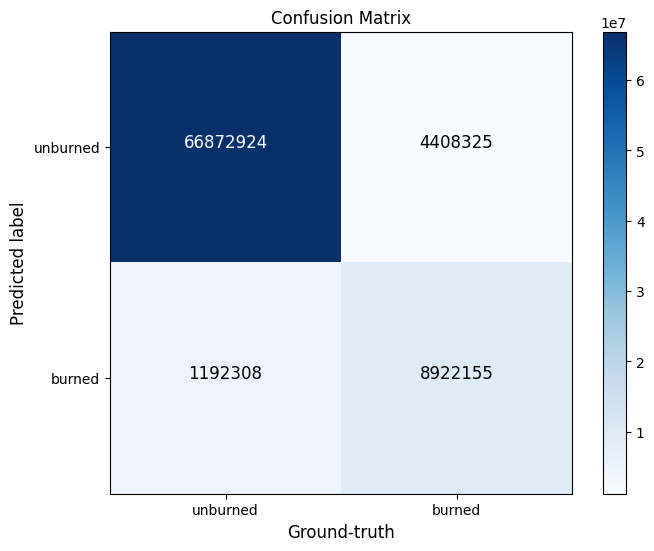

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
plotConfusionMatrix(y_test_argmax.flatten(), y_pred_argmax.flatten(), classes = class_names)

Reshape Patches into Grid:

Reorganizes the flat array of patches into a 2D spatial grid (rows × columns) matching the original tiled layout of the full image, for both image and label data.

In [ ]:
# reshape the image patches
patches = np.reshape(X, (col, row, 256,256,1))
patches = np.expand_dims(patches, axis = 2)
print("Patches array shape is: ", patches.shape)

# reshape the labeling data patches
patches_labels = np.reshape(y, (patches.shape[0], patches.shape[1], 256,256))
print("Patches labeling shape is: ", patches_labels.shape)

Patches array shape is:  (27, 46, 1, 256, 256, 1)
Patches labeling shape is:  (27, 46, 256, 256)


Print Grid Dimensions:

Displays the number of patch rows and columns in the spatial grid for verification before full-image reconstruction.

In [ ]:
# Patches by rows and cols (integer)
num_patches_rows = patches.shape[0]
num_patches_cols = patches.shape[1]
print(f'number of patches in rows: {num_patches_rows}\nnumber of patches in cols: {num_patches_cols}')

number of patches in rows: 27
number of patches in cols: 46


## 14. Predict Patch by Patch on Large Image

Iterates over every patch in the 2D grid, runs inference on each one individually, collects the predicted masks, and reshapes them back into the patch grid structure.

In [ ]:
patch_size = 256
nbands = 1

#Apply the trained model on large image, patch by patch
predicted_patches = []
for i in range(patches.shape[0]):
    for j in range(patches.shape[1]):
        print("Now predicting on patch", i,j)

        single_patch = patches[i,j,0,:,:,:]

        single_patch_input = np.expand_dims(single_patch, axis = 0)
        single_patch_prediction = (model.predict(single_patch_input))
        single_patch_predicted_img = np.argmax(single_patch_prediction, axis = 3)[0,:,:]

        predicted_patches.append(single_patch_predicted_img)

predicted_patches = np.array(predicted_patches)

predicted_patches = np.reshape(predicted_patches, (patches.shape[0], patches.shape[1], patch_size, patch_size))

Now predicting on patch 0 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
Now predicting on patch 0 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Now predicting on patch 0 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Now predicting on patch 0 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Now predicting on patch 0 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Now predicting on patch 0 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Now predicting on patch 0 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now predicting on patch 0 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Now 

Print Predicted Patch Grid Shape:

Displays the shape of the predicted patch grid (rows, cols, height, width) to confirm the reconstruction is ready.

In [ ]:
print(f'number of patches in rows: {predicted_patches.shape[0]}\nnumber of patches in cols: {predicted_patches.shape[1]}')
print(f'shape of patches: {predicted_patches.shape[2]}, {predicted_patches.shape[3]}')

number of patches in rows: 27
number of patches in cols: 46
shape of patches: 256, 256


Print Predicted Patches Shape:

Prints the full shape of the predicted_patches array as a final check before mosaicking.

In [ ]:
print(f'shape of patches: {predicted_patches.shape}')

shape of patches: (27, 46, 256, 256)


## 15. Reconstruct Full Image from Patches

Uses unpatchify to stitch all patch-level predictions, input images, and ground-truth labels back into their original full spatial extent.

In [ ]:
# reconstructing the whole image and labeling data
reconstructed_pred = unpatchify(predicted_patches, (num_patches_rows*patch_size, num_patches_cols*patch_size))
reconstructed_image = unpatchify(patches, (num_patches_rows*patch_size, num_patches_cols*patch_size, nbands))
reconstructed_labels = unpatchify(patches_labels, (num_patches_rows*patch_size, num_patches_cols*patch_size))

Define Target Image Dimensions:

Sets the exact row and column dimensions of the original full-size raster (e.g., Canada study area) to match the GeoTIFF reference image when padding the reconstructed output.

In [ ]:
rd = reconstructed_pred

# Tst1 - Portugal
nrows = 10063
ncols = 13107

#Tst2 - Spain
#nrows = 10253
#ncols = 12704

# california
#nrows = 10186
#ncols = 12582

# canada
nrows = 7059
ncols = 11803

# Rows and cols to be added
diff_nrows = nrows - rd.shape[0]
diff_ncols = ncols - rd.shape[1]
diff_nrows, diff_ncols

(147, 27)

Pad Reconstructed Prediction to Match Raster Size:

Adds zero-padding rows and columns to the reconstructed prediction array so that its dimensions exactly match the reference GeoTIFF raster extent.

In [ ]:
# Obtaining reconstructued prediction image with the Portugal dimension
burned_area = np.concatenate([rd, np.zeros((rd.shape[0], diff_ncols))], axis=1)
burned_area = np.concatenate([burned_area, np.zeros((diff_nrows, burned_area.shape[1]))], axis=0)
burned_area.shape

(7059, 11803)

## 16. Visualize Full Image: Input, Labels, and Prediction

Displays three side-by-side panels showing the reconstructed NRBR input image, the ground-truth burned area labels, and the full model prediction across the entire test region.

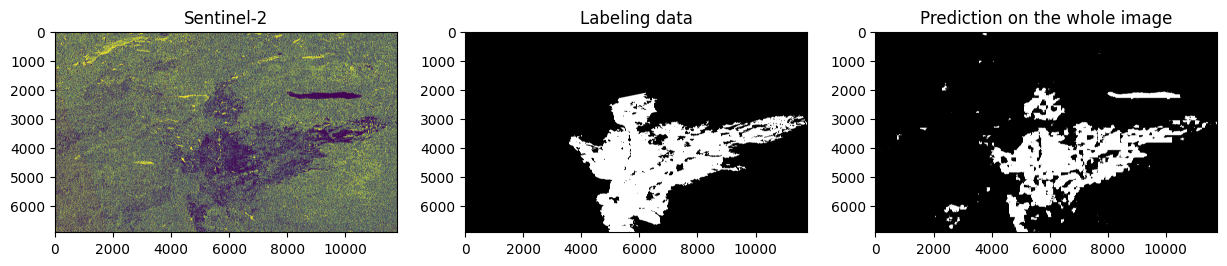

In [ ]:
# histogram with percentiles
def hist_percentile(arr_rgb):
  p10 = np.nanpercentile(arr_rgb, 10) # percentile10
  p90 = np.nanpercentile(arr_rgb, 90) # percentile90
  clipped_arr = np.clip(arr_rgb, p10, p90)
  arr_rgb_norm = (clipped_arr - p10)/(p90 - p10)
  return arr_rgb_norm

orig_map = plt.colormaps['Greys']
reversed_map = orig_map.reversed()
img = reconstructed_image

fig, ax = plt.subplots(1, 3, figsize = (15,9))

#rgb_patch = hist_percentile(np.dstack((img[:,:,9], img[:,:,6], img[:,:,2])))
ax[0].imshow(img, vmin=-0.5, vmax=1)
ax[0].set_title('Sentinel-2')
ax[1].imshow(reconstructed_labels, cmap = reversed_map)
ax[1].set_title('Labeling data')
ax[2].imshow(reconstructed_pred,cmap = reversed_map)
ax[2].set_title('Prediction on the whole image')
plt.show()

## 17. Save Burned Area Prediction as GeoTIFF

Exports the final reconstructed burned area prediction as a GeoTIFF file to Google Drive, preserving the original geospatial reference of the study area.

In [ ]:
!pip install scikeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 73.3 MB/s eta 0:00:00


In [ ]:
import rasterio

# Path of folder
data_dir = "/content/drive/MyDrive/00_PhD/papers/03/dataset/Canada"
path_raster = data_dir + '/' + "NRBR_Can.tif"
# Reading a raster band
band = rasterio.open(path_raster)

In [ ]:
from scikeo.writeRaster import writeRaster

In [ ]:
# Saving the whole image prediction
writeRaster(arr = burned_area,
            image = band,
            filename = 'TST4_label_Canada',
            filepath = data_dir,
            n = 1)